# EE200 Course Project - Q1

## Group Members: 
Utkarsh Aman 241114

Manish Kajla 240622

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Q1A. Frequency Forensics - 'The Ghost Signal'
### Mathematical Background

**The 2D Discrete Fourier Transform (DFT):**
For an image of size $M \times N$, the 2D DFT $F(u, v)$ is defined as:
$$F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) e^{-j2\pi (\frac{ux}{M} + \frac{vy}{N})}$$

**The Inverse 2D Discrete Fourier Transform (IDFT):**
To reconstruct the spatial image $f(x, y)$ from its frequency components:
$$f(x, y) = \frac{1}{MN} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} F(u, v) e^{j2\pi (\frac{ux}{M} + \frac{vy}{N})}$$



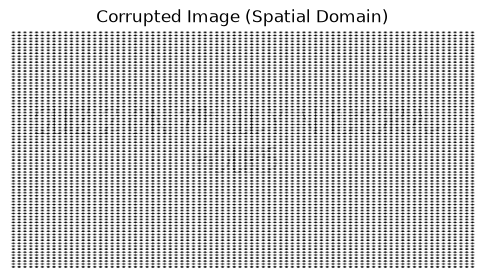

In [3]:
img_path = 'Q1_data/ghost_signal_input.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Corrupted Image (Spatial Domain)')
plt.axis('off')
plt.show()

### 1. Transform to Frequency Domain
We compute the 2D Discrete Fourier Transform (DFT) and shift the zero-frequency component to the center. Then we plot the magnitude spectrum in both linear and logarithmic (dB) scales.

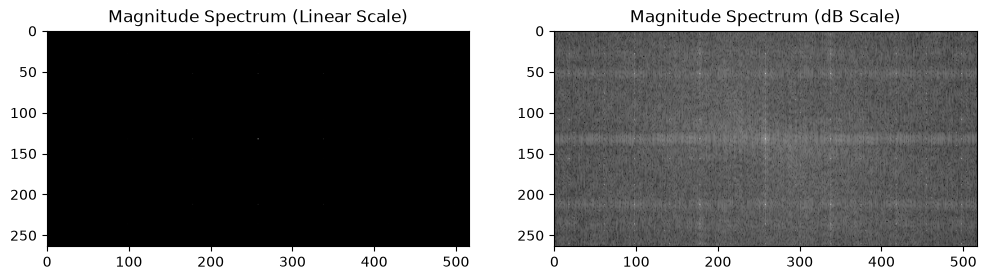

In [4]:
F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

magnitude_spectrum_linear = np.abs(F_shift)
magnitude_spectrum_db = 20 * np.log10(magnitude_spectrum_linear + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(magnitude_spectrum_linear, cmap='gray')
axes[0].set_title('Magnitude Spectrum (Linear Scale)')
axes[1].imshow(magnitude_spectrum_db, cmap='gray')
axes[1].set_title('Magnitude Spectrum (dB Scale)')
plt.show()

### 2. Identifying and Filtering the Interference
Periodic interference appears as distinct bright spots (spikes) in the magnitude spectrum away from the center. We will create a filter to suppress these specific frequencies. Since we want to remove specific frequencies, we will use a notch filter (setting the highest non-center peaks to zero).

**Centering the Spectrum:**
The raw DFT output has the zero-frequency (DC) component at the top-left corner. We apply `fftshift` to move the low frequencies to the center, which is done by multiplying the spatial image by $(-1)^{x+y}$ or rearranging quadrants. This makes the spectrum easier to interpret visually.

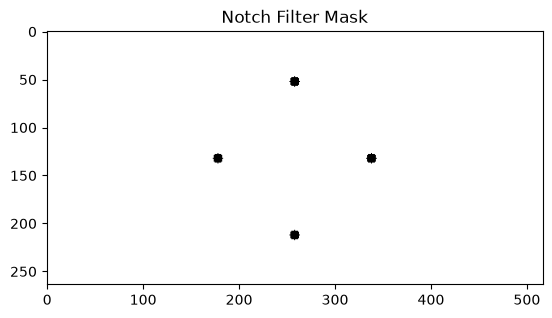

In [5]:
rows, cols = img.shape
crow, ccol = rows//2 , cols//2

# Automatically find the top peaks excluding the center (low frequencies)
mag_copy = np.copy(magnitude_spectrum_linear)
# Mask out the central region (useful image content)
mask_radius = 30
cv2.circle(mag_copy, (ccol, crow), mask_radius, 0, -1)

# Find the coordinates of the maximum peaks (interference)
# We'll filter out the highest spikes symmetrically
num_peaks = 4 
filter_mask = np.ones((rows, cols), np.uint8)
notch_radius = 5

for i in range(num_peaks):
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(mag_copy)
    if max_val > 0:
        cv2.circle(filter_mask, max_loc, notch_radius, 0, -1)
        # Zero out the local region in mag_copy so we can find the next peak
        cv2.circle(mag_copy, max_loc, notch_radius, 0, -1)

plt.imshow(filter_mask, cmap='gray')
plt.title('Notch Filter Mask')
plt.show()

### 3. Reconstructing the Image
Apply the filter mask in the frequency domain and use the Inverse 2D DFT to reconstruct the spatial image.

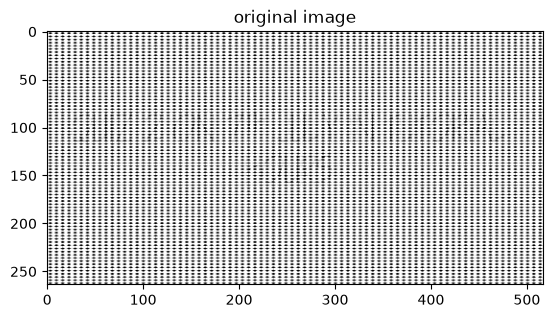

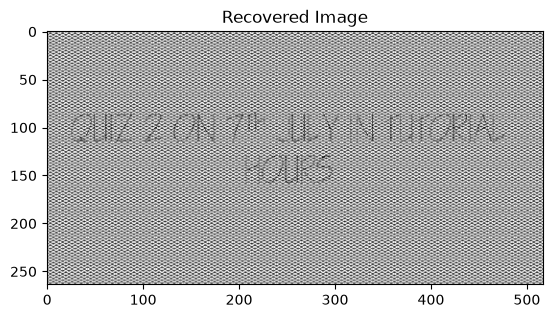

In [6]:
F_shift_filtered = F_shift * filter_mask
F_ishift = np.fft.ifftshift(F_shift_filtered)
img_back = np.fft.ifft2(F_ishift)
img_recovered = np.abs(img_back)



plt.imshow(img, cmap='gray')
plt.title('original image')
plt.show()

plt.imshow(img_recovered, cmap='gray')
plt.title('Recovered Image')
plt.show()

## Q1B. Digital Detective - 'Missing Boundaries'


**Edge Detection Theory:**
Edges correspond to high-frequency components where intensity changes rapidly. The **Sobel Filter** approximates the gradient of the image intensity:
- $G_x$: Detects vertical edges (horizontal changes).
- $G_y$: Detects horizontal edges (vertical changes).
- $G = \sqrt{G_x^2 + G_y^2}$: Represents the total gradient magnitude.

**The Role of Smoothing:**
Noise consists of random, high-frequency fluctuations. Derivatives (gradients) are highly sensitive to these fluctuations. By applying a Gaussian Blur, we perform low-pass filtering to remove this noise. As shown in the difference plot, smoothing allows the Sobel operator to focus on the 'true' object boundaries rather than the 'false' edges created by noise.

Let's apply the Sobel filter to detect edges. We will compare the results with and without image smoothing (noise reduction).


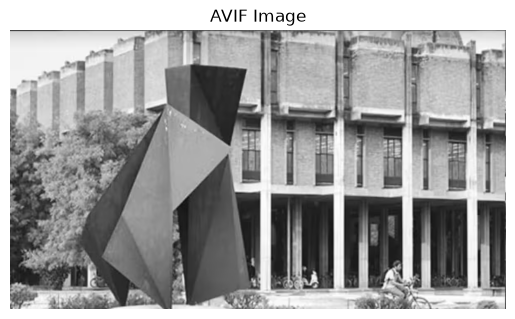

In [7]:
from PIL import Image

img_path = 'Q1_data/missing_boundaries_input.avif'


image_pil = Image.open(img_path)
img = np.array(image_pil)

#display
plt.imshow(img)
plt.axis('off')
plt.title("AVIF Image")
plt.show()


In [8]:
sobel_x = cv2.Sobel(
    img,
    cv2.CV_64F,
    1, 0,
    ksize=3
)

sobel_y = cv2.Sobel(
    img,
    cv2.CV_64F,
    0, 1,
    ksize=3
)

gradient = np.sqrt( sobel_x**2 + sobel_y**2)

gradient_original = gradient / gradient.max()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..671.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..584.0].


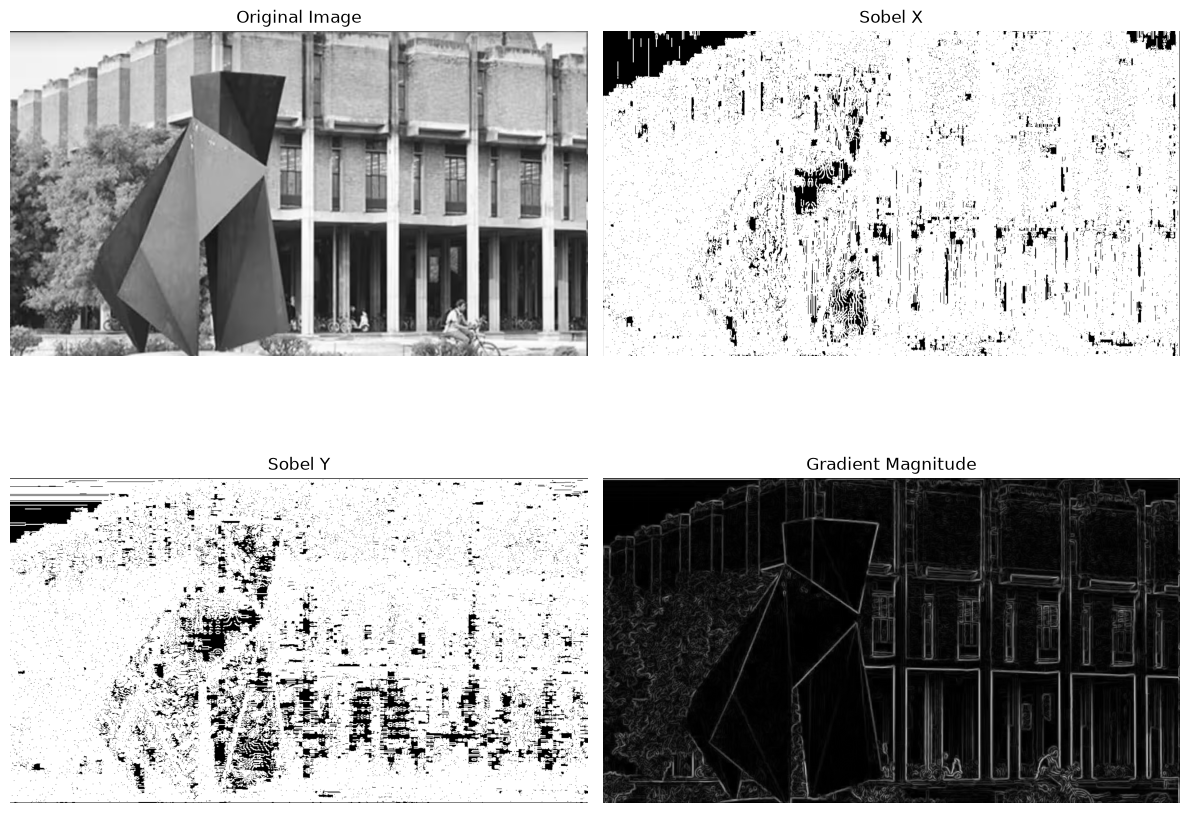

In [9]:
fig, ax = plt.subplots(2,2, figsize=(12,10))

ax[0,0].imshow(img, cmap='gray')
ax[0,0].set_title("Original Image")
ax[0,0].axis('off')

ax[0,1].imshow(np.abs(sobel_x), cmap='gray')
ax[0,1].set_title("Sobel X")
ax[0,1].axis('off')

ax[1,0].imshow(np.abs(sobel_y), cmap='gray')
ax[1,0].set_title("Sobel Y")
ax[1,0].axis('off')

ax[1,1].imshow(gradient_original, cmap='gray')
ax[1,1].set_title("Gradient Magnitude")
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

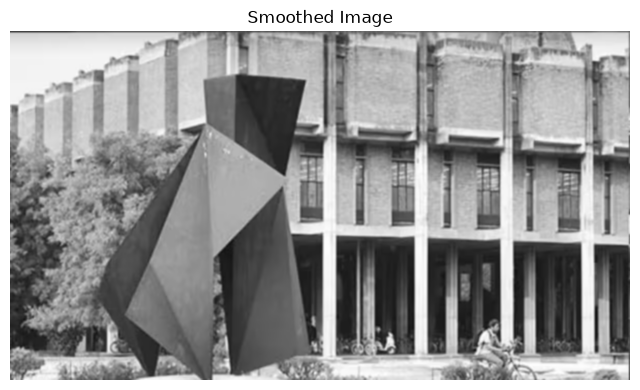

In [10]:
blurred = cv2.GaussianBlur(img, (5,5), 0)

plt.figure(figsize=(8,6))
plt.imshow(blurred, cmap='gray')
plt.title("Smoothed Image")
plt.axis('off')
plt.show()

In [11]:
sobel_x = cv2.Sobel(
    blurred,
    cv2.CV_64F,
    1, 0,
    ksize=3
)

sobel_y = cv2.Sobel(
    blurred,
    cv2.CV_64F,
    0, 1,
    ksize=3
)

gradient = np.sqrt( sobel_x**2 + sobel_y**2)

gradient = gradient / gradient.max()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..436.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..384.0].


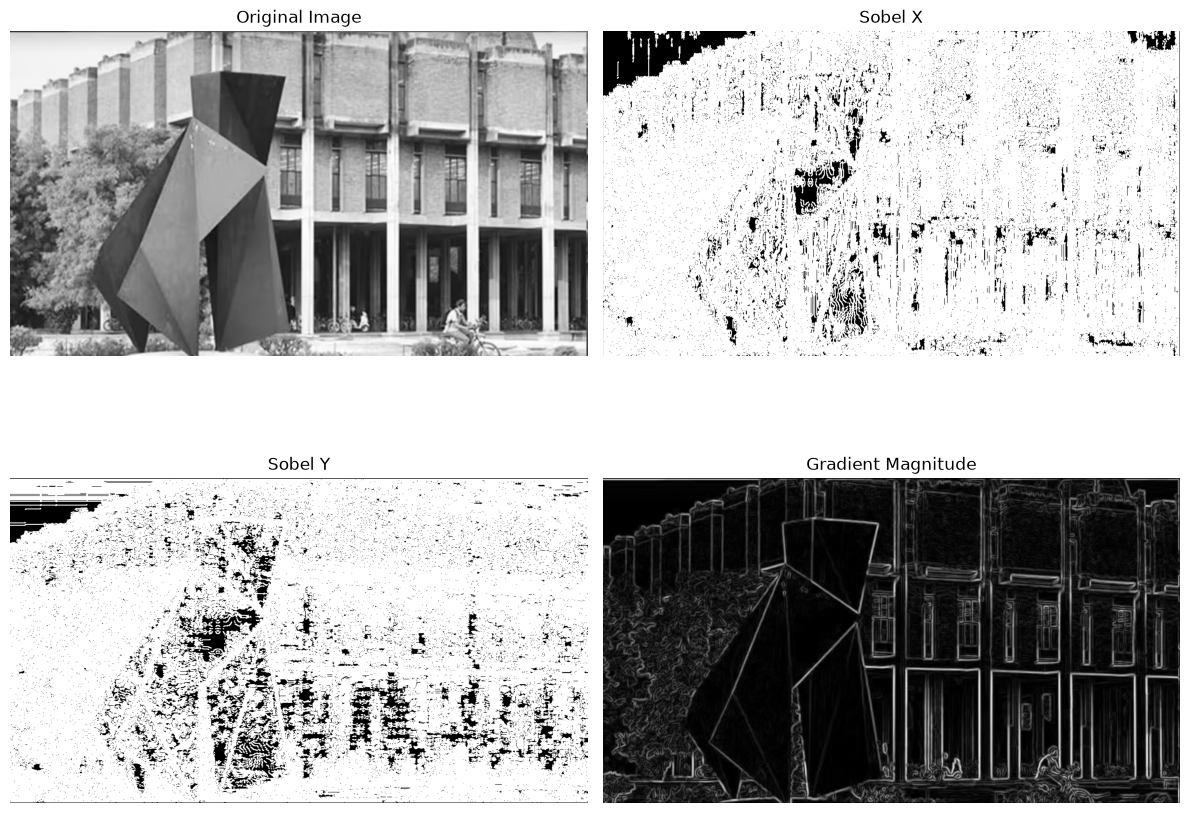

In [12]:
fig, ax = plt.subplots(2,2, figsize=(12,10))

ax[0,0].imshow(img, cmap='gray')
ax[0,0].set_title("Original Image")
ax[0,0].axis('off')

ax[0,1].imshow(np.abs(sobel_x), cmap='gray')
ax[0,1].set_title("Sobel X")
ax[0,1].axis('off')

ax[1,0].imshow(np.abs(sobel_y), cmap='gray')
ax[1,0].set_title("Sobel Y")
ax[1,0].axis('off')

ax[1,1].imshow(gradient, cmap='gray')
ax[1,1].set_title("Gradient Magnitude")
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

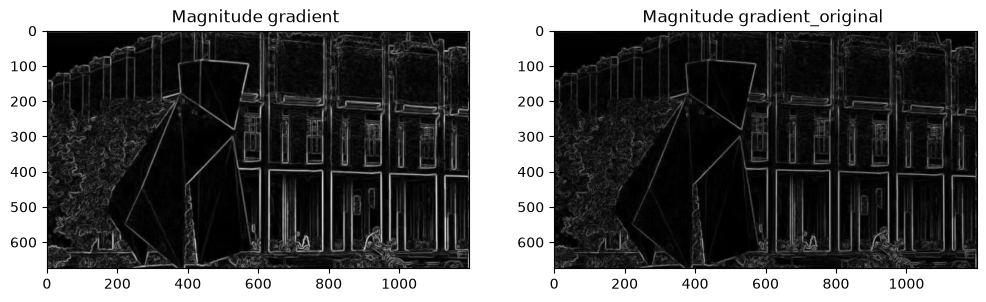

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gradient, cmap='gray')
axes[0].set_title('Magnitude gradient ')
axes[1].imshow(gradient_original, cmap='gray')
axes[1].set_title('Magnitude gradient_original ')
plt.show()

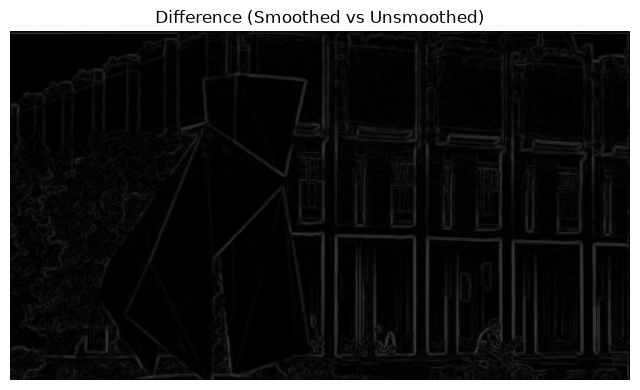

In [14]:
#lets try to compare what differen is in the two
diff = np.abs(gradient - gradient_original)

plt.figure(figsize=(8,6))
plt.imshow(diff, cmap='gray')
plt.title("Difference (Smoothed vs Unsmoothed)")
plt.axis('off')
plt.show()


As seen in the comparison, extracting edges directly from the raw image without smoothing causes the Sobel filter to detect fine, high-frequency background noise as "edges" (visible as speckles in the trees and building walls).

Applying a Gaussian blur before the Sobel filter acts as a low-pass filter. It suppresses this random, high-frequency noise while preserving the strong, low-frequency structural boundaries (like the statue and the building frame). This allows us to cleanly extract the object boundaries without our gradient being overwhelmed by noise.

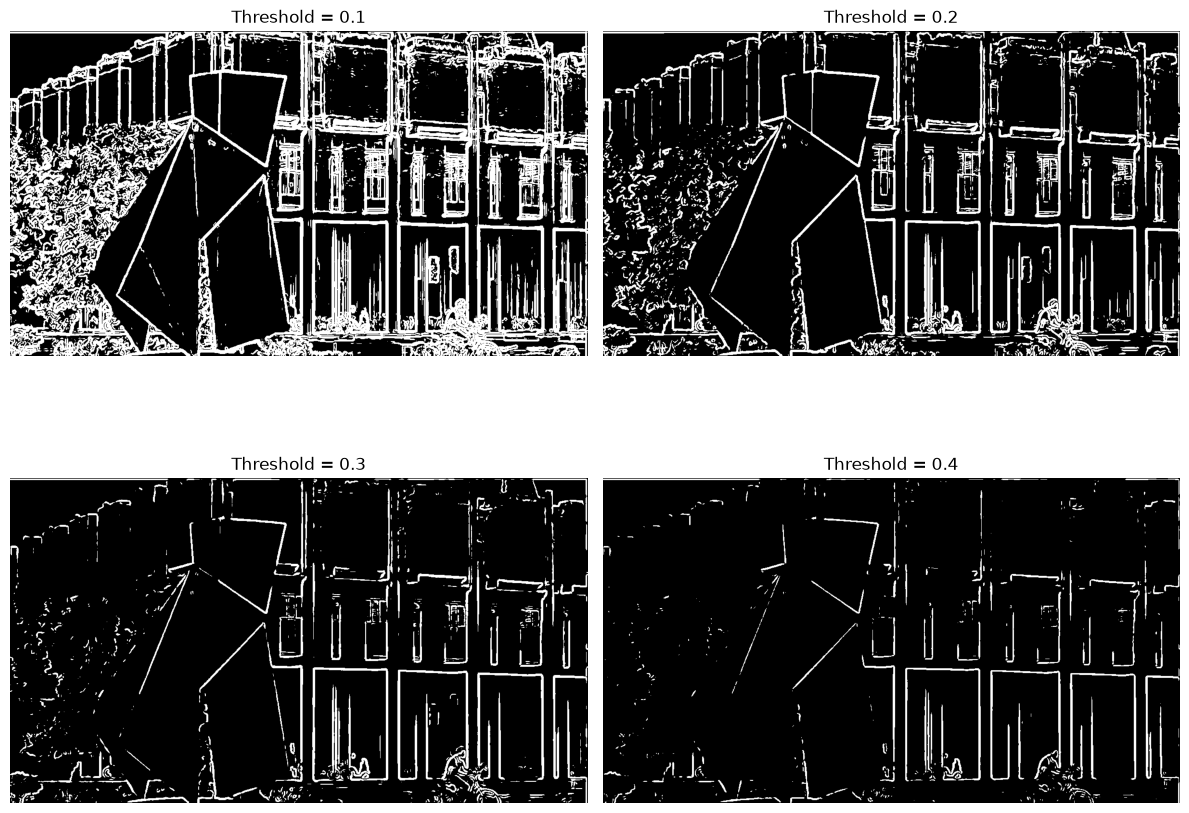

In [16]:
thresholds = [0.1, 0.2, 0.3, 0.4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, threshold in zip(axes.ravel(), thresholds):
    edges = gradient > threshold

    ax.imshow(edges, cmap='gray')
    ax.set_title(f"Threshold = {threshold}")
    ax.axis('off')

plt.tight_layout()
plt.show()